# B0 — RemoteCLIP Zero-Shot Cross-Modal Retrieval Baseline

**Phase 2 of CompRS-CLIP project.** Establishes the lower-bound retrieval performance using frozen RemoteCLIP-ViT-B/32 with no fine-tuning. Also generates the canonical stratified train/val/test split that all subsequent experiments (B1 bi-modal fine-tune, M tri-modal CompRS-CLIP) reuse.

Outputs of this notebook:
1. `splits/comprs_split.csv` — canonical 7000/1000/2000 stratified split.
2. `results/b0_zeroshot.json` — Recall@K (I→T and T→I), mean recall, and inference latency for each caption column.

Run on Kaggle T4. Estimated wall-clock: ~5 minutes (no training).

## 0. Setup & Reproducibility

In [2]:
# --- Install extra dependencies ---
!pip install open_clip_torch --quiet

In [3]:
# --- Imports ---
import json
import math
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import open_clip
from huggingface_hub import hf_hub_download
from sklearn.model_selection import train_test_split

In [4]:
# --- Reproducibility ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device       : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU          : {torch.cuda.get_device_name(0)}')
    total_vram = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f'Total VRAM   : {total_vram:.1f} GB')
print(f'PyTorch      : {torch.__version__}')
print(f'open_clip    : {open_clip.__version__}')

Device       : cuda
GPU          : Tesla T4
Total VRAM   : 14.6 GB
PyTorch      : 2.10.0+cu128
open_clip    : 3.3.0


## 1. Configuration

All paths and experiment parameters live here so downstream cells stay clean. The split sizes (7000/1000/2000) follow the Phase 2 plan and stratify on the dominant land-cover class to keep rare classes (Water, Barren) represented in the test set.

In [6]:
# --- Dataset paths ---
DATASET_ROOT = Path('/kaggle/input/datasets/oooessteii/di725-project-dataset/DI725_project_dataset')
CSV_PATH     = DATASET_ROOT / 'captions.csv'
IMG_DIR      = DATASET_ROOT / 'images'

# --- Output paths ---
SPLIT_DIR    = Path('splits')
RESULTS_DIR  = Path('results')
FIGURE_DIR   = Path('figures')
for d in [SPLIT_DIR, RESULTS_DIR, FIGURE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SPLIT_CSV    = SPLIT_DIR   / 'comprs_split.csv'
RESULTS_JSON = RESULTS_DIR / 'b0_zeroshot.json'

COMP_COLS = ['Tree', 'Shrub', 'Grass', 'Crop', 'Built-up', 'Barren', 'Water']
CAPTION_COLS = [
    'hybrid_gemma3-4b',
    'hybrid_qwen3-vl-8b',
    'text_qwen3-4b',
    'vision_gemma3-4b',
    'vision_qwen3-vl-8b',
]

# --- Split sizes ---
N_TRAIN = 7000
N_VAL   = 1000
N_TEST  = 2000

BATCH_SIZE = 64

# --- Recall cut-offs reported in the literature (RemoteCLIP, RSITMD) ---
K_VALUES = [1, 5, 10]

assert CSV_PATH.exists(), f'captions.csv not found at {CSV_PATH}'
assert IMG_DIR.exists(),  f'images/ folder not found at {IMG_DIR}'

## 2. Data Loading & Stratified Split

Compute a `dominant_class` for each image (argmax over composition columns) and use it as the stratification key. The split is saved and uploaded as dataset so B1 and M reuse identical row assignments, this is essential for fair comparison.

In [7]:
# --- Check the dataset ---
df = pd.read_csv(CSV_PATH)
print(f'Total rows     : {len(df)}')
print(f'Columns        : {list(df.columns)}')
print(f"\n'split' column distribution:")
print(df['split'].value_counts())
print(f'\nNull values    : {df.isnull().sum().sum()}')

Total rows     : 10000
Columns        : ['filename', 'split', 'Tree', 'Shrub', 'Grass', 'Crop', 'Built-up', 'Barren', 'Water', 'hybrid_gemma3-4b', 'hybrid_qwen3-vl-8b', 'text_qwen3-4b', 'vision_gemma3-4b', 'vision_qwen3-vl-8b']

'split' column distribution:
split
synth    10000
Name: count, dtype: int64

Null values    : 0


In [8]:
# --- Compute dominant class for stratification ---
# argmax over the 7 composition columns, then map index back to class name
df['dominant_class'] = df[COMP_COLS].values.argmax(axis=1)
df['dominant_class'] = df['dominant_class'].map(lambda i: COMP_COLS[i])

print('Dominant-class distribution across full dataset:')
print(df['dominant_class'].value_counts())

Dominant-class distribution across full dataset:
dominant_class
Grass       4703
Tree        3037
Crop        1803
Barren       193
Water        178
Built-up      59
Shrub         27
Name: count, dtype: int64


In [9]:
# --- Stratified split ---
# Two-stage split keeps stratification consistent.
# Step 1: 8000 (train+val) vs 2000 (test)
# Step 2: 7000 (train) vs 1000 (val) from the 8000

assert len(df) >= N_TRAIN + N_VAL + N_TEST, (
    f'Dataset has {len(df)} rows but plan needs {N_TRAIN + N_VAL + N_TEST}'
)

# Take first 10000 rows
if len(df) > N_TRAIN + N_VAL + N_TEST:
    df_sub, _ = train_test_split(
        df,
        train_size=N_TRAIN + N_VAL + N_TEST,
        stratify=df['dominant_class'],
        random_state=SEED,
    )
else:
    df_sub = df.copy()

# Step 1: hold out test
df_trainval, df_test = train_test_split(
    df_sub,
    test_size=N_TEST,
    stratify=df_sub['dominant_class'],
    random_state=SEED,
)

# Step 2: train vs val from the remaining 8000
df_train, df_val = train_test_split(
    df_trainval,
    test_size=N_VAL,
    stratify=df_trainval['dominant_class'],
    random_state=SEED,
)

# Tag each row with its split, then concatenate back into one CSV
df_train = df_train.assign(comprs_split='train')
df_val   = df_val.assign(comprs_split='val')
df_test  = df_test.assign(comprs_split='test')
df_split = pd.concat([df_train, df_val, df_test], axis=0).sort_values('filename').reset_index(drop=True)

# Save final split (B1 and M will read from this exact file)
df_split[['filename', 'comprs_split']].to_csv(SPLIT_CSV, index=False)
print(f'Split file saved: {SPLIT_CSV}  ({len(df_split)} rows)')

# Dominant-class distribution should be roughly uniform across splits
print('\nDominant-class proportion per split:')
prop = (df_split.groupby('comprs_split')['dominant_class']
        .value_counts(normalize=True)
        .unstack().fillna(0).round(3))
print(prop)

Split file saved: splits/comprs_split.csv  (10000 rows)

Dominant-class proportion per split:
dominant_class  Barren  Built-up  Crop  Grass  Shrub   Tree  Water
comprs_split                                                      
test             0.020     0.006  0.18   0.47  0.002  0.304  0.018
train            0.019     0.006  0.18   0.47  0.003  0.304  0.018
val              0.019     0.006  0.18   0.47  0.003  0.304  0.018


## 3. Load Frozen RemoteCLIP-ViT-B/32

Same loading recipe as the proof-of-concept (HuggingFace checkpoint loaded into an `open_clip` ViT-B/32 architecture). All parameters frozen, model in `eval()` mode — there is no training in B0.

In [10]:
# --- Just like the Proof of concept, initialize RemoteCLIP from the official github repo guide ---
# https://github.com/ChenDelong1999/RemoteCLIP#load-remoteclip
# Download RemoteCLIP checkpoint
print('Downloading RemoteCLIP-ViT-B-32 weights from HuggingFace...')
checkpoint_path = hf_hub_download(
    repo_id='chendelong/RemoteCLIP',
    filename='RemoteCLIP-ViT-B-32.pt',
    cache_dir='checkpoints',
)
print(f'Checkpoint at: {checkpoint_path}')

# --- Initialize ViT-B/32 architecture ---
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms('ViT-B-32')
state_dict = torch.load(checkpoint_path, map_location='cpu')
clip_model.load_state_dict(state_dict)
clip_tokenizer = open_clip.get_tokenizer('ViT-B-32')

clip_model = clip_model.to(DEVICE)
for p in clip_model.parameters():
    p.requires_grad = False
clip_model.eval()

n_params = sum(p.numel() for p in clip_model.parameters())
print(f'RemoteCLIP-ViT-B/32 loaded  |  total params: {n_params:,}  |  all frozen')

RemoteCLIP-ViT-B-32.pt:   0%|          | 0.00/605M [00:00<?, ?B/s]

Checkpoint at: checkpoints/models--chendelong--RemoteCLIP/snapshots/bf1d8a3ccf2ddbf7c875705e46373bfe542bce38/RemoteCLIP-ViT-B-32.pt


RemoteCLIP-ViT-B/32 loaded  |  total params: 151,277,313  |  all frozen


## 4. Test Dataset & Loader

Minimal dataset for B0 — returns the image tensor and the row index.

In [11]:
class TestImageDataset(Dataset):
    """Returns image tensor and the row index for matching with captions later."""
    def __init__(self, df, img_dir, transform):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.img_dir / row["filename"]
        try:
            image = Image.open(img_path).convert("RGB")
        except FileNotFoundError:
            # just in case
            image = Image.new("RGB", (224, 224), (0, 0, 0))
        return self.transform(image), idx

# Build the test set from the canonical split
df_test_only = df_split[df_split["comprs_split"] == "test"].reset_index(drop=True)
test_ds = TestImageDataset(df_test_only, IMG_DIR, clip_preprocess)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)

print(f"Test set size  : {len(df_test_only)}")
print(f"Test batches   : {len(test_loader)}  (batch_size={BATCH_SIZE})")

Test set size  : 2000
Test batches   : 32  (batch_size=64)


## 5. Encode Test-Set Images

In [12]:
@torch.no_grad()
def encode_images(model, loader, device):
    """Encode all images, return L2-normalized (N, 512) tensor on CPU."""
    embs = []
    for imgs, _ in loader:
        imgs = imgs.to(device, non_blocking=True)
        e = model.encode_image(imgs)
        e = F.normalize(e, dim=-1)
        embs.append(e.cpu())
    return torch.cat(embs, dim=0)

t0 = time.time()
img_embs = encode_images(clip_model, test_loader, DEVICE)
print(f"Image embeddings : {tuple(img_embs.shape)}  "
      f"(L2 norm mean={img_embs.norm(dim=-1).mean():.4f})")
print(f"Encoding time    : {time.time() - t0:.1f}s")

Image embeddings : (2000, 512)  (L2 norm mean=1.0000)
Encoding time    : 13.6s


## 6. Retrieval Evaluation Function

Computes Recall@K for both directions (Image→Text and Text→Image) given pre-encoded embeddings. Pool size = number of test items (2000), so this is a 2000-way retrieval task.

Mean Recall (mR) = mean of {I2T R@1, I2T R@5, I2T R@10, T2I R@1, T2I R@5, T2I R@10}, the standard summary metric in the RemoteCLIP / RSITMD benchmarks.

In [14]:
def retrieval_metrics(img_embs, txt_embs, k_values=(1, 5, 10)):
    """
    Both inputs are L2-normalized (N, D) tensors.
    Diagonal entries (i, i) are the matched pairs; everything else is a distractor.
    Returns a dict with R@k for I2T and T2I, plus mean recall (mR).
    """
    assert img_embs.shape == txt_embs.shape, "Image and text embedding shapes must match"
    N = img_embs.shape[0]
    sim = img_embs @ txt_embs.T # (N, N), rows = image queries
    targets = torch.arange(N)

    out = {}
    # Image -> Text (rows are image queries)
    for k in k_values:
        topk = sim.topk(k, dim=1).indices # (N, k)
        hits = (topk == targets.unsqueeze(1)).any(dim=1).float().mean().item()
        out[f"i2t_R@{k}"] = hits * 100 # report as percentage

    # Text -> Image (transpose: rows are text queries)
    sim_t = sim.T
    for k in k_values:
        topk = sim_t.topk(k, dim=1).indices
        hits = (topk == targets.unsqueeze(1)).any(dim=1).float().mean().item()
        out[f"t2i_R@{k}"] = hits * 100

    out["mR"] = float(np.mean([out[f"i2t_R@{k}"] for k in k_values] +
                              [out[f"t2i_R@{k}"] for k in k_values]))
    return out

## 7. Evaluate Zero-Shot Retrieval Across All 5 Caption Columns

Image embeddings stay fixed; re-encode text per caption column. This reveals which caption column gives RemoteCLIP its strongest zero-shot signal, used for choosing which captions to fine-tune on in B1 and M.

In [15]:
@torch.no_grad()
def encode_captions(model, tokenizer, captions, device, batch_size=64):
    """Tokenize and encode a list of caption strings into (N, 512) L2-normalized tensor."""
    embs = []
    for i in range(0, len(captions), batch_size):
        batch = captions[i:i + batch_size]
        tokens = tokenizer(batch).to(device)
        e = model.encode_text(tokens)
        e = F.normalize(e, dim=-1)
        embs.append(e.cpu())
    return torch.cat(embs, dim=0)

# Run zero-shot retrieval for each caption column
zeroshot_results = {}
for col in CAPTION_COLS:
    captions = df_test_only[col].astype(str).tolist()
    txt_embs = encode_captions(clip_model, clip_tokenizer, captions, DEVICE)
    metrics = retrieval_metrics(img_embs, txt_embs, K_VALUES)
    zeroshot_results[col] = metrics
    print(f"{col:<24}  "
          f"I2T R@1={metrics['i2t_R@1']:5.2f}  R@5={metrics['i2t_R@5']:5.2f}  R@10={metrics['i2t_R@10']:5.2f}  "
          f"|  T2I R@1={metrics['t2i_R@1']:5.2f}  R@5={metrics['t2i_R@5']:5.2f}  R@10={metrics['t2i_R@10']:5.2f}  "
          f"|  mR={metrics['mR']:5.2f}")

hybrid_gemma3-4b          I2T R@1= 0.50  R@5= 1.60  R@10= 2.50  |  T2I R@1= 0.10  R@5= 1.30  R@10= 2.10  |  mR= 1.35
hybrid_qwen3-vl-8b        I2T R@1= 0.45  R@5= 1.35  R@10= 2.35  |  T2I R@1= 0.25  R@5= 0.95  R@10= 2.05  |  mR= 1.23
text_qwen3-4b             I2T R@1= 0.25  R@5= 1.20  R@10= 1.80  |  T2I R@1= 0.20  R@5= 0.65  R@10= 1.25  |  mR= 0.89
vision_gemma3-4b          I2T R@1= 0.50  R@5= 2.40  R@10= 3.75  |  T2I R@1= 0.30  R@5= 1.65  R@10= 3.30  |  mR= 1.98
vision_qwen3-vl-8b        I2T R@1= 0.70  R@5= 2.15  R@10= 3.00  |  T2I R@1= 0.60  R@5= 1.95  R@10= 3.15  |  mR= 1.93


In [16]:
# --- Display as DataFrame ---
results_df = pd.DataFrame(zeroshot_results).T
results_df = results_df[["i2t_R@1", "i2t_R@5", "i2t_R@10",
                         "t2i_R@1", "t2i_R@5", "t2i_R@10", "mR"]]
results_df = results_df.round(2)
print("\nZero-Shot RemoteCLIP - Recall@K (%) on test set (N=2000):\n")
print(results_df.to_string())


Zero-Shot RemoteCLIP - Recall@K (%) on test set (N=2000):

                    i2t_R@1  i2t_R@5  i2t_R@10  t2i_R@1  t2i_R@5  t2i_R@10    mR
hybrid_gemma3-4b       0.50     1.60      2.50     0.10     1.30      2.10  1.35
hybrid_qwen3-vl-8b     0.45     1.35      2.35     0.25     0.95      2.05  1.23
text_qwen3-4b          0.25     1.20      1.80     0.20     0.65      1.25  0.89
vision_gemma3-4b       0.50     2.40      3.75     0.30     1.65      3.30  1.98
vision_qwen3-vl-8b     0.70     2.15      3.00     0.60     1.95      3.15  1.93


## 8. Inference Latency Measurement

Per-query encoding latency for image and text branches. Sets the baseline to compare for 'negligible inference overhead' claim from the proposal. B1 and M will be measured against this in their own notebooks. Wwarm up the GPU first, then time over 100 forward passes.

In [17]:
@torch.no_grad()
def measure_latency(fn, n_warmup=10, n_trials=100):
    """Average wall-clock per call after warmup, with cuda sync."""
    for _ in range(n_warmup):
        fn()
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(n_trials):
        fn()
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return (time.time() - t0) / n_trials * 1000  # ms

# Single-sample latency (per-query)
sample_img = next(iter(test_loader))[0][:1].to(DEVICE)
sample_tok = clip_tokenizer([df_test_only.iloc[0]["hybrid_qwen3-vl-8b"]]).to(DEVICE)

img_latency_ms  = measure_latency(lambda: clip_model.encode_image(sample_img))
text_latency_ms = measure_latency(lambda: clip_model.encode_text(sample_tok))

print(f"Single-sample inference latency (RemoteCLIP, batch=1):")
print(f"  Image branch : {img_latency_ms:.3f} ms / query")
print(f"  Text  branch : {text_latency_ms:.3f} ms / query")

Single-sample inference latency (RemoteCLIP, batch=1):
  Image branch : 6.250 ms / query
  Text  branch : 7.185 ms / query


## 9. Save Results

In [18]:
# --- Persist results for downstream use if needed ---
final = {
    "model"           : "RemoteCLIP-ViT-B/32 (zero-shot, frozen)",
    "test_set_size"   : len(df_test_only),
    "k_values"        : K_VALUES,
    "per_caption"     : zeroshot_results,
    "latency_ms"      : {
        "image_per_query": img_latency_ms,
        "text_per_query" : text_latency_ms,
    },
    "split_csv"       : str(SPLIT_CSV),
    "seed"            : SEED,
}

with open(RESULTS_JSON, "w") as f:
    json.dump(final, f, indent=2)
print(f"Results saved: {RESULTS_JSON}")

Results saved: results/b0_zeroshot.json


/tmp/ipykernel_55/306241894.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CAPTION_COLS, rotation=20, ha="right", fontsize=8)


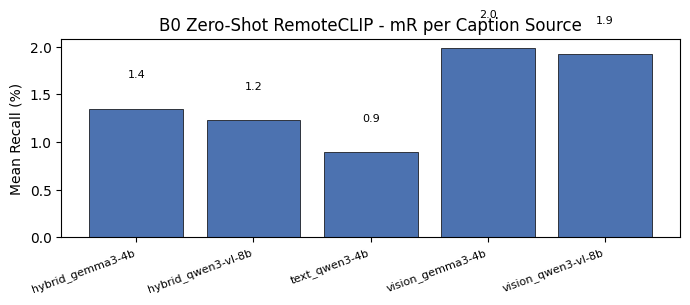

Figure saved: figures/b0_mR_per_caption.png


In [19]:
# --- Quick visual: mR per caption column ---
fig, ax = plt.subplots(figsize=(7, 3.2))
mrs = [zeroshot_results[c]["mR"] for c in CAPTION_COLS]
bars = ax.bar(CAPTION_COLS, mrs, color="#4C72B0", edgecolor="black", linewidth=0.5)
ax.set_ylabel("Mean Recall (%)")
ax.set_title("B0 Zero-Shot RemoteCLIP - mR per Caption Source")
ax.set_xticklabels(CAPTION_COLS, rotation=20, ha="right", fontsize=8)
for bar, val in zip(bars, mrs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{val:.1f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "b0_mR_per_caption.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Figure saved: {FIGURE_DIR / 'b0_mR_per_caption.png'}")